# GALAX Classification Demo

This notebook demonstrates how to use GALAX for spatial classification analysis with Buffalo 311 call request data (categorized).

## Contents
1. Data Loading and Preprocessing
2. Model Configuration
3. Model Fitting
4. Results Visualization

In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from galax.GALAX import GALAX
from joblib import load

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

/mmfs1/home/wqu8/env/automl312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Preprocessing

In [2]:
data = pd.read_csv("../data/311Request_class.csv")

print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:")
data.head()

Dataset shape: (290, 22)

First few rows:


,GEO_ID,snow depth,% below poverty,% civilian unemployed,% capita income,% no high school,% 65 older,% 17 younger,% household disability,% single parent household,...,% multi unit,% mobile homes,% crowding,% no vehicle,% group quarters,historical requests,neighbor historical request,Lon,Lat,311_requests
0,360299800001,164.639636,0.000000,0.087629,4494,0.000000,0.000000,0.025768,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,1.000000,0.003838,0.114875,325494,325913,0
1,360299805001,139.546979,0.142857,0.000000,6786,0.123077,0.035129,0.035129,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.964871,0.012881,0.129964,331141,328130,0
2,360290071044,190.124982,0.637097,0.166667,11913,0.341346,0.055780,0.302419,0.540952,0.639723,...,0.393728,0.0,0.070476,0.403810,0.000000,0.034946,0.037469,324919,321303,0
3,360290031004,190.481889,0.595825,0.123967,14560,0.105140,0.100000,0.221818,0.159021,1.000000,...,0.758410,0.0,0.000000,0.828746,0.085455,0.060000,0.148579,326885,322132,0
4,360290067024,177.446804,0.112867,0.000000,30386,0.112867,0.216704,0.000000,0.139037,0.000000,...,0.708494,0.0,0.018717,0.425134,0.000000,0.067720,0.121151,326190,322493,0


In [6]:
columns_to_exclude = ['CBG ID', 'Lon', 'Lat', '311_requests']
x_vars = [column for column in data.columns if column not in columns_to_exclude]

print(f"Feature variables ({len(x_vars)}): {x_vars}")

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(data[x_vars])
y = data['311_requests'].values
coords = data[['Lon', 'Lat']].values

Feature variables (19): ['GEO_ID', 'snow depth', '% below poverty', '% civilian unemployed', '% capita income', '% no high school', '% 65 older', '% 17 younger', '% household disability', '% single parent household', '% minority', '% not well english', '% multi unit', '% mobile homes', '% crowding', '% no vehicle', '% group quarters', 'historical requests', 'neighbor historical request']


## 2. Model Configuration

In [4]:
automl_settings = {
    "time_budget": 180,  # Time budget in seconds
    "estimator_list": ['rf', 'xgboost', 'xgb_limitdepth', 'extra_tree'],
    "task": 'classification',
    "metric": 'accuracy',
    "seed": 42,
    "verbose": 0,
}

## 3. Model Fitting

GALAX will automatically select the optimal bandwidth using Incremental Spatial Autocorrelation (ISA) and fit local classification models at each location.

In [5]:
model = GALAX(
    coords=coords,
    y=y,
    X=X,
    bw='isa',
    kernel='bisquare',
    automl_settings=automl_settings,
    task='classification',
    n_jobs=16,
    x_vars=x_vars
)

results = model.fit()

Starting ISA bandwidth selection...

Starting bandwidth search:
- Minimum bandwidth: 21
- Maximum bandwidth: 276
- Step size: 1
- Minimum samples per class: 5
--------------------------------------------------
Task: Classification
Number of samples: 290
Unique classes: [0 1 2 3 4]
Number of classes: 5
--------------------------------------------------

Testing bandwidth 21 (1/256)...

Found 289 locations with class size issues:
Location 0:
  Problems: Classes with insufficient samples: [(np.int64(0), np.int64(4)), (np.int64(1), np.int64(4)), (np.int64(3), np.int64(4)), (np.int64(4), np.int64(4))]
  Class counts: {np.int64(0): np.int64(4), np.int64(1): np.int64(4), np.int64(2): np.int64(5), np.int64(3): np.int64(4), np.int64(4): np.int64(4)}
Location 1:
  Problems: Classes with insufficient samples: [(np.int64(0), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(3), np.int64(3))]
  Class counts: {np.int64(0): np.int64(2), np.int64(1): np.int64(3), np.int64(2): np.int64(7), np.int64(3

## 4. Results Summary and Visualization

In [7]:
results.summary()

GALAX Results Summary
--------------------------------------------------
Task: classification
Bandwidth: 208
Global Accuracy: 0.8241
Global Precision: 0.8362
Global Recall: 0.8241
Global F1 Score: 0.8191
Local Precision Statistics:
  - Mean: 0.6606
  - Min: 0.3609
  - Max: 1.0000
  - Std: 0.1289


### Save Results

In [8]:
results.save_results('../results/GALAX_classification_results.joblib')
print("Results saved to ../results/GALAX_classification_results.joblib")

Results saved to ../results/GALAX_classification_results.joblib


### Spatial Distribution of Local Precision

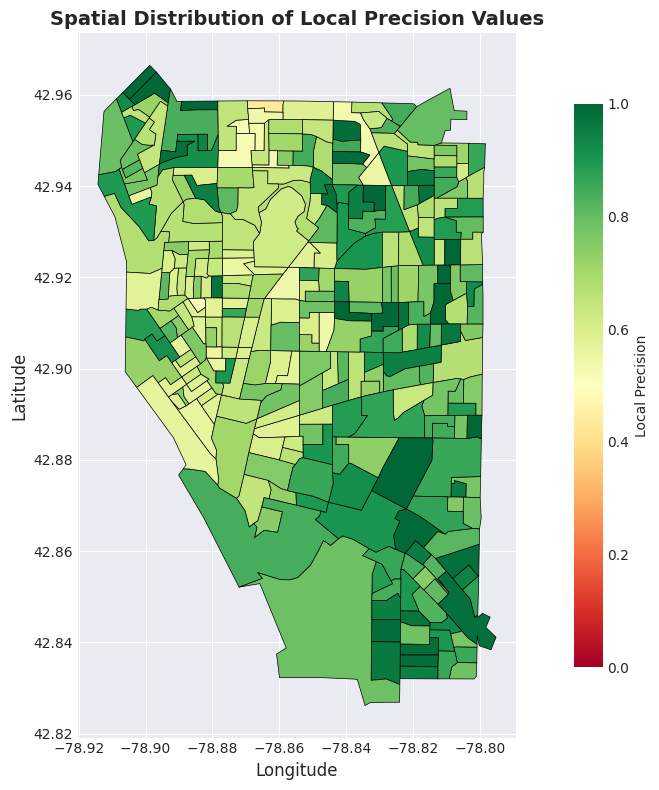

In [10]:
buffalo_cbgs = gpd.read_file('../data/buffalo/buffalo.shp')

# Create a DataFrame with GEO_ID and Local Precision values
local_precision_data = pd.DataFrame({
    'GEO_ID': data['GEO_ID'].astype(str),
    'Local_Precision': results.local_metrics
})

# Merge CBG geometries with Local Precision data
buffalo_cbgs['GEOID'] = buffalo_cbgs['GEOID'].astype(str)
merged_cbgs = buffalo_cbgs.merge(local_precision_data, left_on='GEOID', right_on='GEO_ID')

fig, ax = plt.subplots(figsize=(12, 8))

merged_cbgs.plot(column='Local_Precision', 
                 cmap='RdYlGn', 
                 ax=ax,
                 edgecolor='black', 
                 linewidth=0.5,
                 vmin=0, 
                 vmax=1,
                 legend=True,
                 legend_kwds={'label': 'Local Precision', 'shrink': 0.8})

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Spatial Distribution of Local Precision Values', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../results/classification_precision.png', dpi=300, bbox_inches='tight')
plt.show()

### Spatial Variation in Feature Importance

Visualize how feature importance varies across space for the historical requests feature.

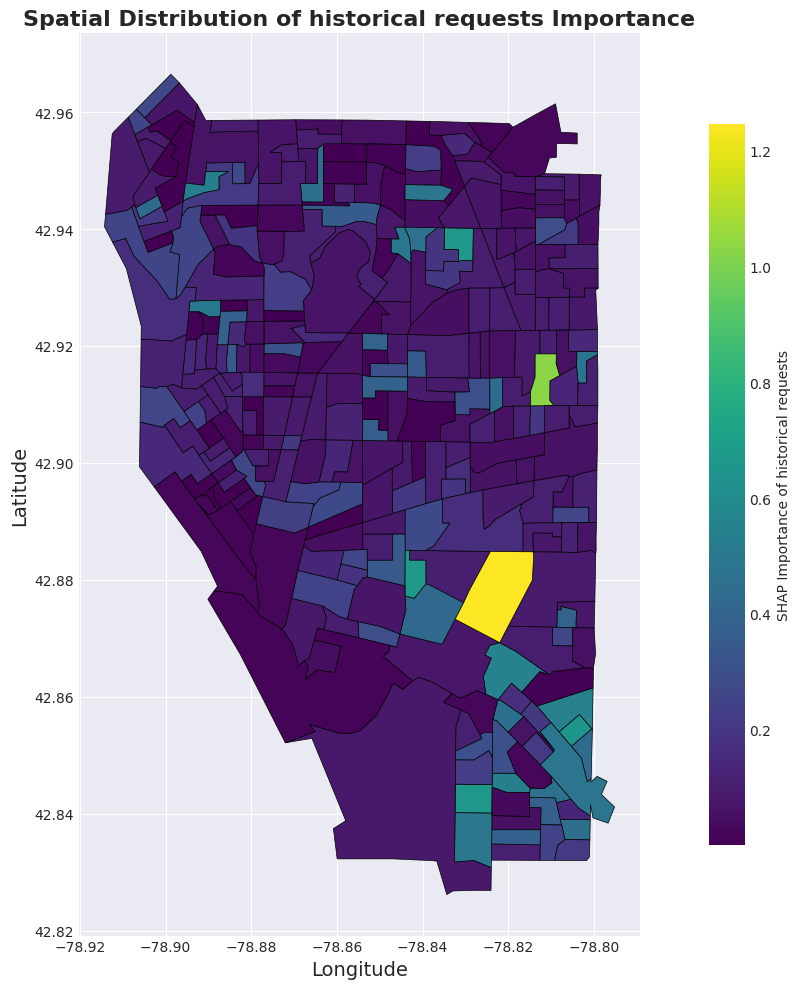

In [ ]:
saved_results = load('../results/GALAX_classification_results.joblib')

target_variable = "historical requests"

# Index of the target variable in x_vars
target_idx = x_vars.index(target_variable)

location_results = saved_results['location_results']
variable_shap_values = []
location_indices = []

for loc_result in location_results:
    if 'raw_shap_values_neighbors' in loc_result and loc_result['raw_shap_values_neighbors'] is not None:
        raw_shap_values = loc_result['raw_shap_values_neighbors']
        location_idx = loc_result['location_index']

        neighbor_shaps = []
        for neighbor_shap in raw_shap_values:
            neighbor_array = np.array(neighbor_shap)
            if neighbor_array.shape == (len(x_vars), 5):
                var_across_classes = neighbor_array[target_idx, :]
                neighbor_shaps.append(np.mean(np.abs(var_across_classes)))

        if neighbor_shaps:
            variable_shap_values.append(float(np.mean(neighbor_shaps)))
            location_indices.append(location_idx)

# Build DataFrame and merge with CBG polygons
historical_requests_data = pd.DataFrame({
    'GEO_ID': data.iloc[location_indices]['GEO_ID'].astype(str),
    'Historical_Requests_SHAP': variable_shap_values
})

buffalo_cbgs['GEOID'] = buffalo_cbgs['GEOID'].astype(str)
merged_historical_cbgs = buffalo_cbgs.merge(historical_requests_data, left_on='GEOID', right_on='GEO_ID')

fig, ax = plt.subplots(figsize=(14, 10))
merged_historical_cbgs.plot(
    column='Historical_Requests_SHAP',
    cmap='viridis',
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': f'SHAP Importance of {target_variable}', 'shrink': 0.8}
)

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title(f'Spatial Distribution of {target_variable} Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig('../results/classification_feature.png', dpi=300, bbox_inches='tight')
plt.show()